# 03 — Evaluation & Export
### Digit Recognizer — CNN Project | Notebook 3 of 3

**Environment:** Google Colab

**Scope:** Load `best_model.pth`, evaluate it properly (confusion matrix,
classification report, precision/recall/F1 — none of which existed in the
original notebook, which only tracked accuracy), plot training curves, and
generate the final Kaggle `submission.csv` (**Existing Implementation,
preserved** — same inference logic as the original notebook).

In [1]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/digit-recognizer-cnn"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

X = train.drop(columns=['label'])
y = train['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
print(X_val.shape, test.shape)

(4200, 784) (28000, 784)


## 1. Rebuild model class & load `best_model.pth`

Same `SimpleCNN` definition as Notebook 2 (also mirrored in
`app/model_def.py`).

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "best_model.pth"), map_location=device))
model.eval()
print("Loaded best_model.pth")

Loaded best_model.pth


## 2. Confusion Matrix & Classification Report — **New**

The original notebook only ever printed a single accuracy number. This adds
the standard evaluation suite (precision/recall/F1 per class, confusion
matrix) needed to actually understand *where* the model struggles — this is
the only proper evaluation available since the Kaggle `test.csv` has no
public labels.

In [5]:
X_val_np = X_val.values.reshape(-1, 1, 28, 28).astype('float32') / 255.0
y_val_np = y_val.values.astype('int64')

val_tensor = torch.tensor(X_val_np)
with torch.no_grad():
    preds = []
    for i in range(0, len(val_tensor), 256):
        batch = val_tensor[i:i+256].to(device)
        out = model(batch)
        preds.append(out.argmax(1).cpu().numpy())
y_pred = np.concatenate(preds)

report = classification_report(y_val_np, y_pred, digits=4, output_dict=True)
print(classification_report(y_val_np, y_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(y_val_np, y_pred, average='weighted')
val_accuracy = (y_pred == y_val_np).mean()
print(f"Overall val_accuracy={val_accuracy:.4f} precision={precision:.4f} recall={recall:.4f} f1={f1:.4f}")

              precision    recall  f1-score   support

           0     1.0000    0.9926    0.9963       408
           1     0.9979    0.9958    0.9968       471
           2     0.9929    0.9952    0.9941       420
           3     0.9960    0.9960    0.9960       506
           4     1.0000    0.9924    0.9962       397
           5     0.9970    0.9853    0.9911       339
           6     0.9950    0.9975    0.9963       402
           7     0.9909    0.9932    0.9920       438
           8     0.9828    0.9950    0.9889       403
           9     0.9881    0.9952    0.9916       416

    accuracy                         0.9940      4200
   macro avg     0.9941    0.9938    0.9939      4200
weighted avg     0.9941    0.9940    0.9941      4200

Overall val_accuracy=0.9940 precision=0.9941 recall=0.9940 f1=0.9941


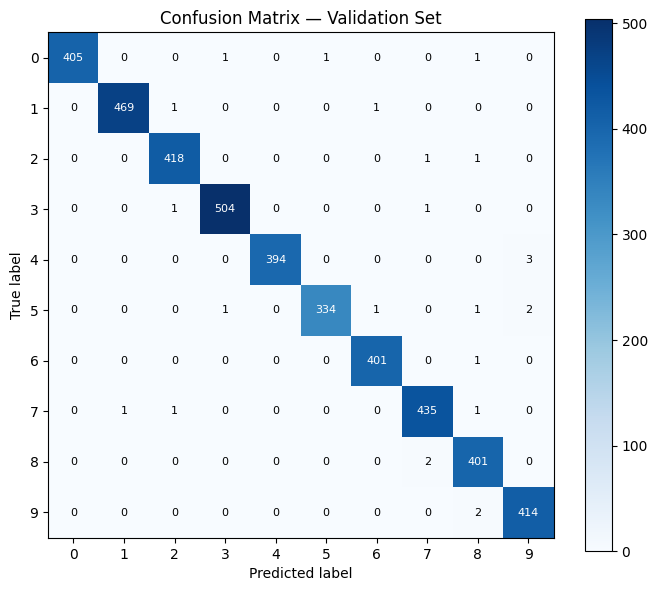

Saved confusion_matrix.png


In [6]:
cm = confusion_matrix(y_val_np, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix — Validation Set")
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Predicted label"); plt.ylabel("True label")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print("Saved confusion_matrix.png")

## 3. Training curves — **New**

Loads `training_history.pkl` from Notebook 2 to plot loss/accuracy across
epochs for both runs, letting you visually confirm augmentation's effect
and check for overfitting — this visibility didn't exist in the original
notebook.

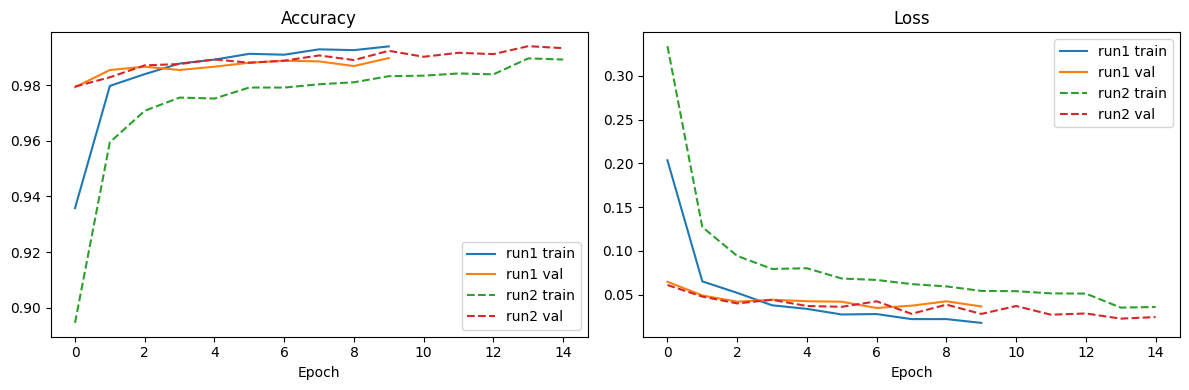

Saved accuracy_plot.png and loss_plot.png


In [7]:
with open(os.path.join(OUTPUTS_DIR, "training_history.pkl"), "rb") as f:
    hist = pickle.load(f)

run1, run2 = hist["run1_no_aug"], hist["run2_augmented"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(run1["train_acc"], label="run1 train")
axes[0].plot(run1["val_acc"], label="run1 val")
axes[0].plot(run2["train_acc"], label="run2 train", linestyle='--')
axes[0].plot(run2["val_acc"], label="run2 val", linestyle='--')
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(run1["train_loss"], label="run1 train")
axes[1].plot(run1["val_loss"], label="run1 val")
axes[1].plot(run2["train_loss"], label="run2 train", linestyle='--')
axes[1].plot(run2["val_loss"], label="run2 val", linestyle='--')
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "accuracy_plot.png"), dpi=150)
plt.savefig(os.path.join(OUTPUTS_DIR, "loss_plot.png"), dpi=150)
plt.show()
print("Saved accuracy_plot.png and loss_plot.png")

## 4. Save consolidated evaluation metrics — **New**

Combines the Notebook 1 baseline with this notebook's CNN metrics into one
`evaluation_metrics.json`, used by the README and the resume bullet points.

In [8]:
baseline_path = os.path.join(OUTPUTS_DIR, "baseline_metrics.json")
baseline = json.load(open(baseline_path)) if os.path.exists(baseline_path) else None

evaluation_metrics = {
    "baseline_random_forest": baseline,
    "cnn_best_model": {
        "val_accuracy": float(val_accuracy),
        "precision_weighted": float(precision),
        "recall_weighted": float(recall),
        "f1_weighted": float(f1),
        "best_val_acc_run1_no_aug": hist["best_val_acc_run1"],
        "best_val_acc_run2_augmented": hist["best_val_acc_run2"],
    },
}

with open(os.path.join(OUTPUTS_DIR, "evaluation_metrics.json"), "w") as f:
    json.dump(evaluation_metrics, f, indent=2)

print("Saved evaluation_metrics.json")
evaluation_metrics

Saved evaluation_metrics.json


{'baseline_random_forest': {'model': 'RandomForestClassifier',
  'n_estimators': 100,
  'random_state': 42,
  'val_accuracy': 0.9611904761904762},
 'cnn_best_model': {'val_accuracy': 0.9940476190476191,
  'precision_weighted': 0.9940782657536956,
  'recall_weighted': 0.9940476190476191,
  'f1_weighted': 0.9940520292858676,
  'best_val_acc_run1_no_aug': 0.9897619047619047,
  'best_val_acc_run2_augmented': 0.9940476190476191}}

## 5. Final Kaggle submission — **Existing Implementation, preserved**

Same batch-inference logic as the original notebook (`batch_size=256`,
`argmax` over logits), now run once, from the single best checkpoint,
producing the final `submission.csv`.

In [9]:
X_test_np = test.values.reshape(-1, 1, 28, 28).astype('float32') / 255.0
X_test_tensor = torch.tensor(X_test_np)

all_preds = []
with torch.no_grad():
    for i in range(0, len(X_test_tensor), 256):
        batch = X_test_tensor[i:i+256].to(device)
        out = model(batch)
        all_preds.append(out.argmax(1).cpu().numpy())
all_preds = np.concatenate(all_preds)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(all_preds) + 1),
    "Label": all_preds
})
submission.to_csv(os.path.join(OUTPUTS_DIR, "submission.csv"), index=False)
print("Saved submission.csv —", submission.shape)
submission.head()

Saved submission.csv — (28000, 2)


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


## 6. Summary

All Colab-side artifacts are now saved to `outputs/` and `models/` on Drive:

- `models/best_model.pth`, `models/final_model.pth`, `models/run1_best.pth`
- `outputs/baseline_metrics.json`, `outputs/evaluation_metrics.json`
- `outputs/training_history.pkl`
- `outputs/confusion_matrix.png`, `outputs/accuracy_plot.png`, `outputs/loss_plot.png`
- `outputs/submission.csv`

**Next:** download `best_model.pth` from Drive into the local
`digit-recognizer-cnn/models/` folder for the VS Code app (`app/`) — the
app only loads this file, it never retrains.